In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Data Balancing
from imblearn.over_sampling import SMOTE

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_excel('Dataset.csv.xlsx')

df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 309 non-null    object
 1   AGE                    309 non-null    int64 
 2   SMOKING                309 non-null    int64 
 3   YELLOW_FINGERS         309 non-null    int64 
 4   ANXIETY                309 non-null    int64 
 5   PEER_PRESSURE          309 non-null    int64 
 6   CHRONIC DISEASE        309 non-null    int64 
 7   FATIGUE                309 non-null    int64 
 8   ALLERGY                309 non-null    int64 
 9   WHEEZING               309 non-null    int64 
 10  ALCOHOL CONSUMING      309 non-null    int64 
 11  COUGHING               309 non-null    int64 
 12  SHORTNESS OF BREATH    309 non-null    int64 
 13  SWALLOWING DIFFICULTY  309 non-null    int64 
 14  CHEST PAIN             309 non-null    int64 
 15  LUNG_CANCER            

,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
count,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,62.673139,1.563107,1.569579,1.498382,1.501618,1.504854,1.673139,1.556634,1.556634,1.556634,1.579288,1.640777,1.469256,1.556634
std,8.210301,0.496806,0.495938,0.500808,0.500808,0.500787,0.469827,0.497588,0.497588,0.497588,0.494474,0.480551,0.499863,0.497588
min,21.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,57.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,62.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000
75%,69.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,87.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


In [4]:
df.isnull().sum()

GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL CONSUMING        0
COUGHING                 0
SHORTNESS OF BREATH      0
SWALLOWING DIFFICULTY    0
CHEST PAIN               0
LUNG_CANCER              0
dtype: int64

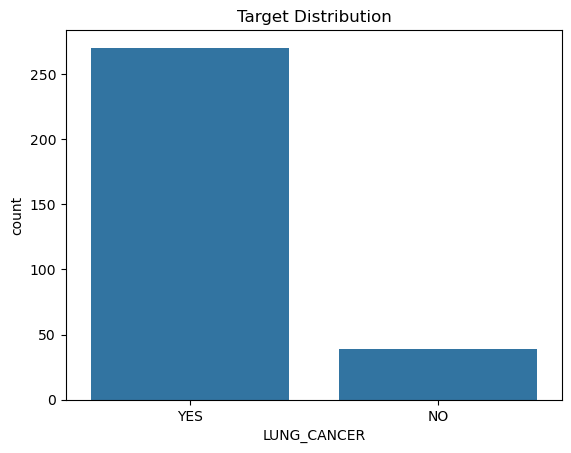

LUNG_CANCER
YES    270
NO      39
Name: count, dtype: int64


In [5]:
sns.countplot(x='LUNG_CANCER', data=df)
plt.title("Target Distribution")
plt.show()

print(df['LUNG_CANCER'].value_counts())

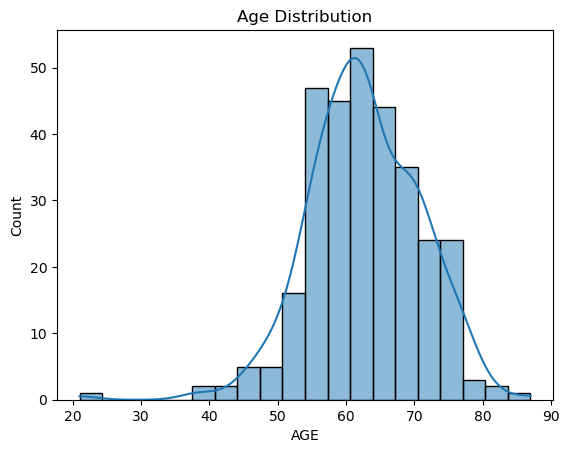

In [6]:
sns.histplot(df['AGE'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

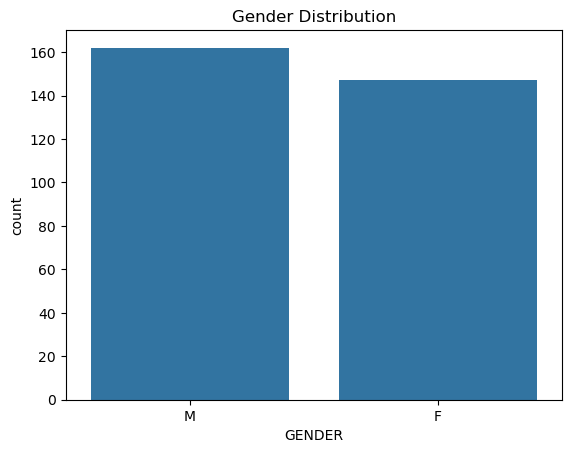

In [7]:
sns.countplot(x='GENDER', data=df)
plt.title("Gender Distribution")
plt.show()

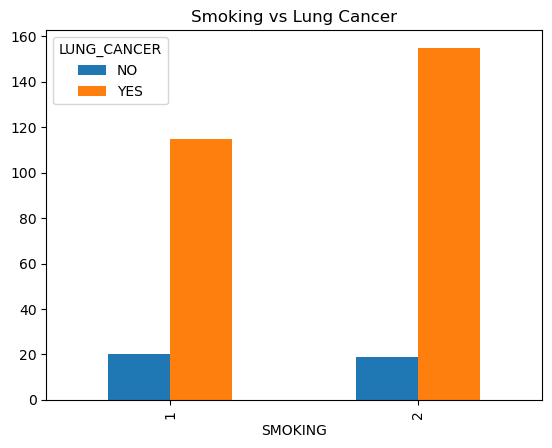

In [8]:
pd.crosstab(df['SMOKING'], df['LUNG_CANCER']).plot(kind='bar')
plt.title("Smoking vs Lung Cancer")
plt.show()

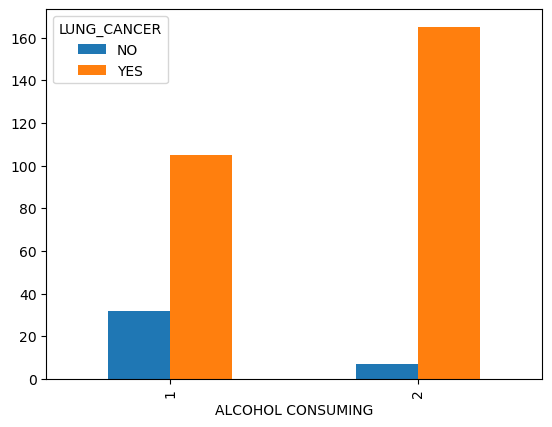

In [9]:
pd.crosstab(df['ALCOHOL CONSUMING'], df['LUNG_CANCER']).plot(kind='bar')
plt.show()

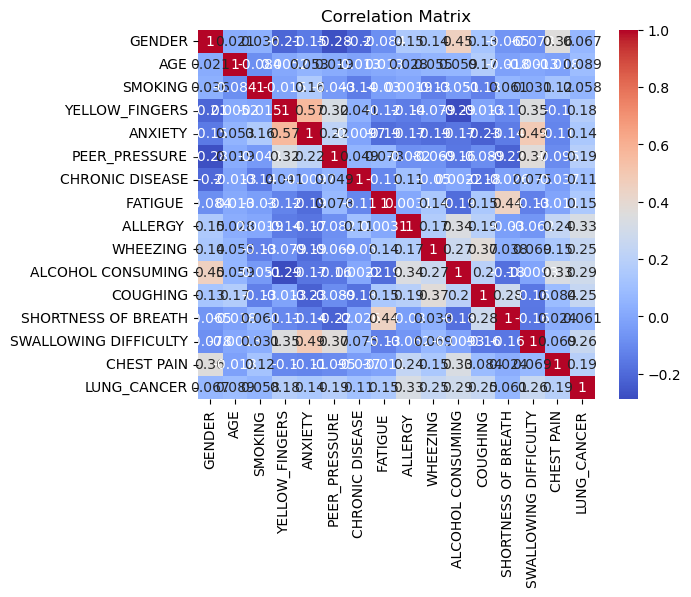

In [10]:
# First encode temporarily
temp_df = df.copy()

temp_df['GENDER'] = temp_df['GENDER'].map({'M': 1, 'F': 0})
temp_df['LUNG_CANCER'] = temp_df['LUNG_CANCER'].map({'YES': 1, 'NO': 0})

sns.heatmap(temp_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [11]:
df['GENDER'] = df['GENDER'].map({'M': 1, 'F': 0})
df['LUNG_CANCER'] = df['LUNG_CANCER'].map({'YES': 1, 'NO': 0})

In [12]:
binary_cols = df.columns[2:-1]

for col in binary_cols:
    df[col] = df[col].map({1: 0, 2: 1})

In [13]:
X = df.drop('LUNG_CANCER', axis=1)
y = df['LUNG_CANCER']

In [14]:
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X, y)

print("Before SMOTE:", X.shape)
print("After SMOTE:", X_resampled.shape)

Before SMOTE: (309, 15)
After SMOTE: (540, 15)


In [20]:
noise = np.random.normal(0, 0.02, X_resampled.shape)
X_augmented = X_resampled + noise

X_final = np.vstack([X_resampled, X_augmented])
y_final = np.hstack([y_resampled, y_resampled])

print(X_final.shape)

(1080, 15)


In [21]:
noise = np.random.normal(0, 0.05, X_resampled.shape)
X_resampled = X_resampled + noise

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    random_state=42
)

In [23]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=200, max_depth=10))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 RandomForestClassifier(max_depth=10, n_estimators=200))])

In [25]:
y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9444444444444444
              precision    recall  f1-score   support

           0       0.98      0.90      0.94        51
           1       0.92      0.98      0.95        57

    accuracy                           0.94       108
   macro avg       0.95      0.94      0.94       108
weighted avg       0.95      0.94      0.94       108



In [27]:
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))

Logistic Regression
              precision    recall  f1-score   support

           0       0.98      0.92      0.95        51
           1       0.93      0.98      0.96        57

    accuracy                           0.95       108
   macro avg       0.96      0.95      0.95       108
weighted avg       0.95      0.95      0.95       108



In [28]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1))
])

xgb_pipeline.fit(X_train, y_train)
y_pred_xgb = xgb_pipeline.predict(X_test)

print("XGBoost")
print(classification_report(y_test, y_pred_xgb))

XGBoost
              precision    recall  f1-score   support

           0       0.96      0.90      0.93        51
           1       0.92      0.96      0.94        57

    accuracy                           0.94       108
   macro avg       0.94      0.93      0.93       108
weighted avg       0.94      0.94      0.94       108



In [29]:
from sklearn.svm import SVC

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='rbf', probability=True))
])

svm_pipeline.fit(X_train, y_train)
y_pred_svm = svm_pipeline.predict(X_test)

print("SVM")
print(classification_report(y_test, y_pred_svm))

SVM
              precision    recall  f1-score   support

           0       0.98      0.92      0.95        51
           1       0.93      0.98      0.96        57

    accuracy                           0.95       108
   macro avg       0.96      0.95      0.95       108
weighted avg       0.95      0.95      0.95       108



In [31]:
models = {
    "Logistic Regression": lr_pipeline,
    "Random Forest": pipeline,
    "XGBoost": xgb_pipeline,
    "SVM" : svm_pipeline
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))


Logistic Regression
Accuracy: 0.9537037037037037

Random Forest
Accuracy: 0.9444444444444444

XGBoost
Accuracy: 0.9351851851851852

SVM
Accuracy: 0.9537037037037037


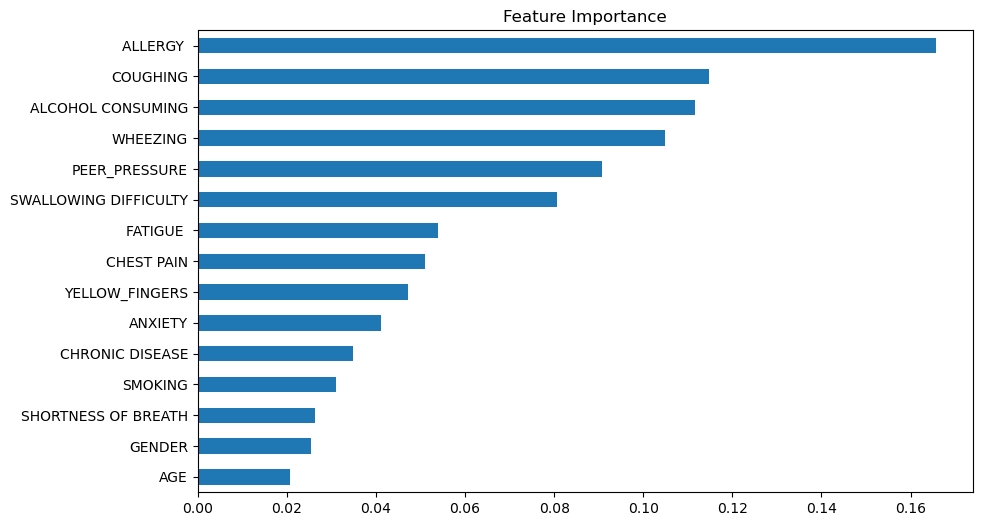

In [26]:
model = pipeline.named_steps['model']

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh', figsize=(10,6))
plt.title("Feature Importance")
plt.show()